<a href="https://colab.research.google.com/github/AlexAndrianov/ICT728_sentiment_and_trend_analysis/blob/Syeda-sanzida-khatun-patch-1/Ict_729_Real_data_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [1]:
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

Load the file

In [5]:
import json

with open("sample_data/converted_social_to_twitter_format.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))
print("Number of records:", len(data))
print(data[0])

<class 'list'>
Number of records: 2964
{'tweet_id': 'facebook_Y29tbWVudDozOTczNzM0OTkzNDQxNDNfOTA2NTc0NzI3NjY5Nzk4', 'username': 'Kat███Dav███on', 'screen_name': 'kat███dav███on', 'content': 'Joy House', 'created_at': '2024-01-12T13:41:08+00:00', 'retweet_count': 0, 'like_count': 0, 'profile_image_url': '', 'posted_hour': 13, 'photos_count': 0, 'videos_count': 0, 'hashtags_count': 0, 'tagged_users_count': 0, 'followers_count': 0, 'posts_count': 0, 'following_count': 0, 'is_verified': False, 'description_error_count': 0, 'swear_word_count': 0, 'word_count': 2, 'emoji_count': 0, 'uppercase_word_count': 0, 'real_views': None, 'hashtags': '', 'real_sentiment': 'neutral', 'is_dataset_tweet': True}


In [6]:
print(data[0])

{'tweet_id': 'facebook_Y29tbWVudDozOTczNzM0OTkzNDQxNDNfOTA2NTc0NzI3NjY5Nzk4', 'username': 'Kat███Dav███on', 'screen_name': 'kat███dav███on', 'content': 'Joy House', 'created_at': '2024-01-12T13:41:08+00:00', 'retweet_count': 0, 'like_count': 0, 'profile_image_url': '', 'posted_hour': 13, 'photos_count': 0, 'videos_count': 0, 'hashtags_count': 0, 'tagged_users_count': 0, 'followers_count': 0, 'posts_count': 0, 'following_count': 0, 'is_verified': False, 'description_error_count': 0, 'swear_word_count': 0, 'word_count': 2, 'emoji_count': 0, 'uppercase_word_count': 0, 'real_views': None, 'hashtags': '', 'real_sentiment': 'neutral', 'is_dataset_tweet': True}


Create DataFrame

In [7]:
import pandas as pd

rows = []
for item in data:
    rows.append({
        "text": item.get("text", ""),
        "hashtags": item.get("hashtags", [])
    })

df = pd.DataFrame(rows)
df = df[df["text"].notna()]
df = df[df["text"] != ""]
df.reset_index(drop=True, inplace=True)

print(df.shape)
df.head()

(0, 2)


,text,hashtags


Clean Text

In [9]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

prepare hashtags

In [10]:
def normalize_hashtags(tags):
    return [str(tag).lower().replace("#", "") for tag in tags if str(tag).strip()]

df["norm_hashtags"] = df["hashtags"].apply(normalize_hashtags)

combine text + hashtags

In [14]:
df["norm_hashtags"] = df["norm_hashtags"].apply(lambda x: x if isinstance(x, list) else [])

df["final_text"] = df["clean_text"] + " " + df["norm_hashtags"].apply(lambda x: " ".join(x))

In [18]:
print(df["final_text"].head(10))
print(df["final_text"].str.len().describe())

Series([], Name: final_text, dtype: object)
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: final_text, dtype: float64


In [19]:
print(type(data))
print(len(data))
print(data[0])

<class 'list'>
2964
{'tweet_id': 'facebook_Y29tbWVudDozOTczNzM0OTkzNDQxNDNfOTA2NTc0NzI3NjY5Nzk4', 'username': 'Kat███Dav███on', 'screen_name': 'kat███dav███on', 'content': 'Joy House', 'created_at': '2024-01-12T13:41:08+00:00', 'retweet_count': 0, 'like_count': 0, 'profile_image_url': '', 'posted_hour': 13, 'photos_count': 0, 'videos_count': 0, 'hashtags_count': 0, 'tagged_users_count': 0, 'followers_count': 0, 'posts_count': 0, 'following_count': 0, 'is_verified': False, 'description_error_count': 0, 'swear_word_count': 0, 'word_count': 2, 'emoji_count': 0, 'uppercase_word_count': 0, 'real_views': None, 'hashtags': '', 'real_sentiment': 'neutral', 'is_dataset_tweet': True}


In [20]:
print(data[0].keys())

dict_keys(['tweet_id', 'username', 'screen_name', 'content', 'created_at', 'retweet_count', 'like_count', 'profile_image_url', 'posted_hour', 'photos_count', 'videos_count', 'hashtags_count', 'tagged_users_count', 'followers_count', 'posts_count', 'following_count', 'is_verified', 'description_error_count', 'swear_word_count', 'word_count', 'emoji_count', 'uppercase_word_count', 'real_views', 'hashtags', 'real_sentiment', 'is_dataset_tweet'])


Rebuilding the dataframe

In [21]:
import pandas as pd

rows = []
for item in data:
    text = item.get("text") or item.get("post_text") or item.get("content") or item.get("caption") or ""
    hashtags = item.get("hashtags") or item.get("tags") or []

    # if hashtags came as one string, convert to list
    if isinstance(hashtags, str):
        hashtags = hashtags.split()

    rows.append({
        "text": str(text),
        "hashtags": hashtags
    })

df = pd.DataFrame(rows)

print("Before cleaning:", df.shape)
print(df.head())

Before cleaning: (2964, 2)
                                                text hashtags
0                                          Joy House       []
1  Yet if a Verizon customer travels outside of t...       []
2        Where is the 5g we was promised 2 years ago       []
3  Your customer service may be the worst on eart...       []
4  And what does this picture suppose to mean? Th...       []


In [22]:
print(df["text"].head(10))
print(df["hashtags"].head(10))
print(df["text"].str.len().describe())

0                                            Joy House
1    Yet if a Verizon customer travels outside of t...
2          Where is the 5g we was promised 2 years ago
3    Your customer service may be the worst on eart...
4    And what does this picture suppose to mean? Th...
5                                            AT&T - ty
6                                       Makes no sense
7    ATT Business customer service is HORRIBLE!  Ta...
8               You suck #period #customerserviceblows
9    Why did AT&T/Direct TV remove non Liberal stat...
Name: text, dtype: object
0                               []
1                               []
2                               []
3                               []
4                               []
5                               []
6                               []
7                               []
8    [period,customerserviceblows]
9                               []
Name: hashtags, dtype: object
count    2964.000000
mean       88.582996
st

Cleaning the text

In [23]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalize_hashtags(tags):
    if isinstance(tags, list):
        return [str(tag).lower().replace("#", "").strip() for tag in tags if str(tag).strip()]
    return []

df["clean_text"] = df["text"].apply(clean_text)
df["norm_hashtags"] = df["hashtags"].apply(normalize_hashtags)

print(df[["text", "clean_text", "norm_hashtags"]].head(10))

                                                text  \
0                                          Joy House   
1  Yet if a Verizon customer travels outside of t...   
2        Where is the 5g we was promised 2 years ago   
3  Your customer service may be the worst on eart...   
4  And what does this picture suppose to mean? Th...   
5                                          AT&T - ty   
6                                     Makes no sense   
7  ATT Business customer service is HORRIBLE!  Ta...   
8             You suck #period #customerserviceblows   
9  Why did AT&T/Direct TV remove non Liberal stat...   

                                          clean_text  \
0                                          joy house   
1  yet if a verizon customer travels outside of t...   
2           where is the g we was promised years ago   
3  your customer service may be the worst on eart...   
4  and what does this picture suppose to mean tha...   
5                                            at

making final text without deleting

In [24]:
df["final_text"] = df["clean_text"] + " " + df["norm_hashtags"].apply(lambda x: " ".join(x))
df["final_text"] = df["final_text"].str.strip()

print(df["final_text"].head(10))
print("Non-empty rows:", (df["final_text"] != "").sum())

0                                            joy house
1    yet if a verizon customer travels outside of t...
2             where is the g we was promised years ago
3    your customer service may be the worst on eart...
4    and what does this picture suppose to mean tha...
5                                              at t ty
6                                       makes no sense
7    att business customer service is horrible talk...
8    you suck period customerserviceblows period,cu...
9    why did at t direct tv remove non liberal stat...
Name: final_text, dtype: object
Non-empty rows: 2414


Removing empty rows

In [25]:
df = df[df["final_text"].notna()]
df = df[df["final_text"].str.strip() != ""].copy()

print("After filtering:", df.shape)
print(df["final_text"].head(10))

After filtering: (2414, 5)
0                                            joy house
1    yet if a verizon customer travels outside of t...
2             where is the g we was promised years ago
3    your customer service may be the worst on eart...
4    and what does this picture suppose to mean tha...
5                                              at t ty
6                                       makes no sense
7    att business customer service is horrible talk...
8    you suck period customerserviceblows period,cu...
9    why did at t direct tv remove non liberal stat...
Name: final_text, dtype: object


using a safer TF-IDF first

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words=None,
    ngram_range=(1, 2),
    min_df=1,
    max_features=5000
)

X = vectorizer.fit_transform(df["final_text"])
print("TF-IDF shape:", X.shape)
print(vectorizer.get_feature_names_out()[:20])

TF-IDF shape: (2414, 5000)
['aben' 'aben oando' 'ability' 'ability to' 'able' 'able to' 'about'
 'about cancelling' 'about customer' 'about it' 'about some' 'about the'
 'about their' 'about this' 'about when' 'absolute' 'absolute worst'
 'absolutely' 'absolutely recommend' 'absolutely worst']


In [27]:
print(data[0])
print(data[0].keys())

{'tweet_id': 'facebook_Y29tbWVudDozOTczNzM0OTkzNDQxNDNfOTA2NTc0NzI3NjY5Nzk4', 'username': 'Kat███Dav███on', 'screen_name': 'kat███dav███on', 'content': 'Joy House', 'created_at': '2024-01-12T13:41:08+00:00', 'retweet_count': 0, 'like_count': 0, 'profile_image_url': '', 'posted_hour': 13, 'photos_count': 0, 'videos_count': 0, 'hashtags_count': 0, 'tagged_users_count': 0, 'followers_count': 0, 'posts_count': 0, 'following_count': 0, 'is_verified': False, 'description_error_count': 0, 'swear_word_count': 0, 'word_count': 2, 'emoji_count': 0, 'uppercase_word_count': 0, 'real_views': None, 'hashtags': '', 'real_sentiment': 'neutral', 'is_dataset_tweet': True}
dict_keys(['tweet_id', 'username', 'screen_name', 'content', 'created_at', 'retweet_count', 'like_count', 'profile_image_url', 'posted_hour', 'photos_count', 'videos_count', 'hashtags_count', 'tagged_users_count', 'followers_count', 'posts_count', 'following_count', 'is_verified', 'description_error_count', 'swear_word_count', 'word_co

Rebuilding dataframe correctly

In [28]:
import pandas as pd
import re

rows = []
for item in data:
    content = item.get("content", "")
    rows.append({
        "content": str(content)
    })

df = pd.DataFrame(rows)

print("Shape:", df.shape)
print(df.head())

Shape: (2964, 1)
                                             content
0                                          Joy House
1  Yet if a Verizon customer travels outside of t...
2        Where is the 5g we was promised 2 years ago
3  Your customer service may be the worst on eart...
4  And what does this picture suppose to mean? Th...


cleaning the content

In [29]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)   # keep hashtag word
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

extract hashtags from the content

In [30]:
def extract_hashtags(text):
    return re.findall(r"#(\w+)", str(text).lower())

create cleaned columns

In [31]:
df["clean_text"] = df["content"].apply(clean_text)
df["norm_hashtags"] = df["content"].apply(extract_hashtags)

print(df[["content", "clean_text", "norm_hashtags"]].head(10))

                                             content  \
0                                          Joy House   
1  Yet if a Verizon customer travels outside of t...   
2        Where is the 5g we was promised 2 years ago   
3  Your customer service may be the worst on eart...   
4  And what does this picture suppose to mean? Th...   
5                                          AT&T - ty   
6                                     Makes no sense   
7  ATT Business customer service is HORRIBLE!  Ta...   
8             You suck #period #customerserviceblows   
9  Why did AT&T/Direct TV remove non Liberal stat...   

                                          clean_text  \
0                                          joy house   
1  yet if a verizon customer travels outside of t...   
2           where is the g we was promised years ago   
3  your customer service may be the worst on eart...   
4  and what does this picture suppose to mean tha...   
5                                            at

combine text + hashtags

In [32]:
df["final_text"] = df["clean_text"] + " " + df["norm_hashtags"].apply(lambda x: " ".join(x))
df["final_text"] = df["final_text"].str.strip()

print(df["final_text"].head(10))
print("Non-empty rows:", (df["final_text"] != "").sum())

0                                            joy house
1    yet if a verizon customer travels outside of t...
2             where is the g we was promised years ago
3    your customer service may be the worst on eart...
4    and what does this picture suppose to mean tha...
5                                              at t ty
6                                       makes no sense
7    att business customer service is horrible talk...
8    you suck period customerserviceblows period cu...
9    why did at t direct tv remove non liberal stat...
Name: final_text, dtype: object
Non-empty rows: 2414


removing empty rows

In [33]:
df = df[df["final_text"].notna()]
df = df[df["final_text"].str.strip() != ""].copy()

print("After filtering:", df.shape)

After filtering: (2414, 4)


TF-IDF

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words=None,
    ngram_range=(1, 2),
    min_df=1,
    max_features=5000
)

X = vectorizer.fit_transform(df["final_text"])

print("TF-IDF shape:", X.shape)
print(vectorizer.get_feature_names_out()[:20])

TF-IDF shape: (2414, 5000)
['aben' 'aben oando' 'ability' 'ability to' 'able' 'able to' 'about'
 'about it' 'about some' 'about the' 'about their' 'about this'
 'about when' 'absolute' 'absolute worst' 'absolutely'
 'absolutely recommend' 'absolutely worst' 'absurd' 'acc']


Clustering

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

results = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X)

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X.toarray(), labels)
    db = davies_bouldin_score(X.toarray(), labels)

    results.append([k, sil, ch, db])

results_df = pd.DataFrame(results, columns=["k", "silhouette", "calinski", "davies"])
print(results_df)

    k  silhouette   calinski    davies
0   2    0.020482  19.555969  9.898331
1   3    0.019903  18.793850  7.965257
2   4    0.023530  15.973993  7.116898
3   5    0.025371  16.760160  6.516185
4   6    0.025241  15.388945  6.634097
5   7    0.022172  13.556410  6.418051
6   8    0.024251  13.325304  6.539462
7   9    0.021826  11.908107  6.842687
8  10    0.022589  12.507009  6.529110


choosing K and train final model

In [36]:
best_k = 5

final_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df["cluster"] = final_model.fit_predict(X)

print(df[["content", "cluster"]].head(10))

                                             content  cluster
0                                          Joy House        3
1  Yet if a Verizon customer travels outside of t...        1
2        Where is the 5g we was promised 2 years ago        1
3  Your customer service may be the worst on eart...        1
4  And what does this picture suppose to mean? Th...        1
5                                          AT&T - ty        3
6                                     Makes no sense        3
7  ATT Business customer service is HORRIBLE!  Ta...        1
8             You suck #period #customerserviceblows        3
9  Why did AT&T/Direct TV remove non Liberal stat...        3


getting names from top words

In [37]:
terms = vectorizer.get_feature_names_out()

def get_cluster_names(model, terms, n_terms=3):
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]
    cluster_names = {}
    for i in range(model.n_clusters):
        top_terms = [terms[ind] for ind in order_centroids[i, :n_terms]]
        cluster_names[i] = " / ".join(top_terms)
    return cluster_names

cluster_names = get_cluster_names(final_model, terms, n_terms=3)
df["trend_name"] = df["cluster"].map(cluster_names)

print(cluster_names)

{0: 'you / to / thank you', 1: 'the / and / to', 2: 'happy / happy birthday / birthday', 3: 'is / beautiful / this', 4: 'love / love it / love this'}


comparing cluster with extract hashtags

In [38]:
from collections import Counter

cluster_hashtag_summary = {}

for cluster_id in sorted(df["cluster"].unique()):
    cluster_tags = []
    cluster_posts = df[df["cluster"] == cluster_id]

    for tags in cluster_posts["norm_hashtags"]:
        cluster_tags.extend(tags)

    top_tags = Counter(cluster_tags).most_common(10)
    cluster_hashtag_summary[cluster_id] = top_tags

for cid, tags in cluster_hashtag_summary.items():
    print(f"\nCluster {cid} - Trend: {cluster_names[cid]}")
    print("Top hashtags:", tags)


Cluster 0 - Trend: you / to / thank you
Top hashtags: [('pixel8pro', 1), ('first', 1), ('best', 1)]

Cluster 1 - Trend: the / and / to
Top hashtags: [('1', 1), ('3', 1), ('leadership', 1), ('transformation', 1), ('growth', 1), ('s', 1), ('teamwork', 1), ('viralgoals', 1), ('supportcreators', 1), ('tiktokcommunity', 1)]

Cluster 2 - Trend: happy / happy birthday / birthday
Top hashtags: []

Cluster 3 - Trend: is / beautiful / this
Top hashtags: [('sae', 5), ('simecatlantisenergy', 5), ('sales', 2), ('crm', 2), ('period', 1), ('customerserviceblows', 1), ('hailing', 1), ('stopfundingfox', 1), ('npp', 1), ('crosswordpuzzleday', 1)]

Cluster 4 - Trend: love / love it / love this
Top hashtags: []


showing number of posts of each cluster

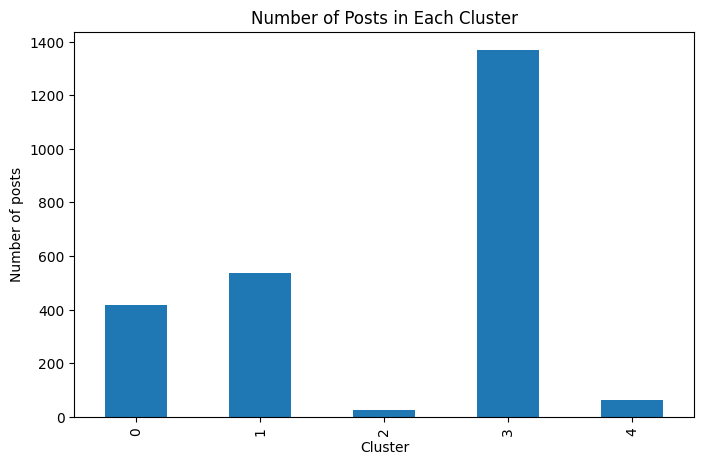

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of posts")
plt.title("Number of Posts in Each Cluster")
plt.show()

plot silhouette graph

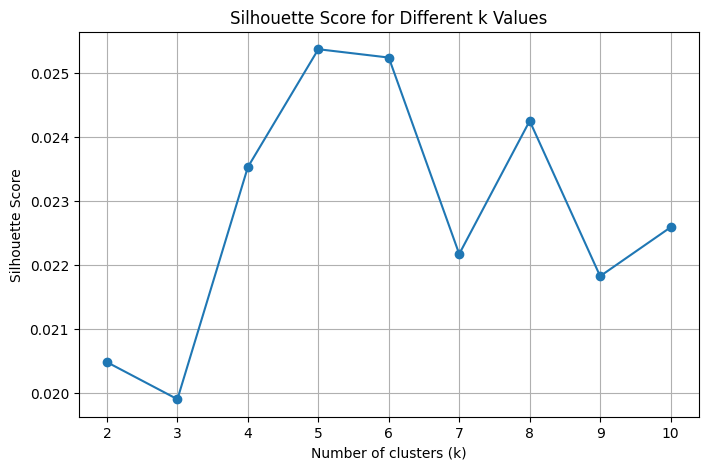

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k Values")
plt.grid(True)
plt.show()

removing very short posts

In [41]:
df = df[df["final_text"].str.split().apply(len) >= 4].copy()

TF-IDF

In [42]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.85,
    max_features=3000
)

trying dimensionality reduction before KMeans

In [43]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)

adding SVD

In [44]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)

clustering on improved data

In [45]:
results = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_reduced)

    sil = silhouette_score(X_reduced, labels)
    ch = calinski_harabasz_score(X_reduced, labels)
    db = davies_bouldin_score(X_reduced, labels)

    results.append([k, sil, ch, db])

results_df = pd.DataFrame(results, columns=["k", "silhouette", "calinski", "davies"])
print(results_df)

    k  silhouette   calinski    davies
0   2    0.036558  61.054766  5.263349
1   3    0.045362  61.222945  3.834128
2   4    0.049054  58.250248  3.290474
3   5    0.052578  52.997779  2.961405
4   6    0.059849  54.363442  2.722488
5   7    0.039524  45.220919  3.131325
6   8    0.065747  50.586306  2.800969
7   9    0.066372  48.317731  2.393230
8  10    0.079749  48.438719  2.617245


final model

In [48]:
print("df rows:", len(df))

df rows: 1827


In [49]:
vectorizer = TfidfVectorizer(
    stop_words=None,
    ngram_range=(1, 2),
    min_df=1,
    max_features=5000
)

X = vectorizer.fit_transform(df["final_text"])

print("X shape:", X.shape)

X shape: (1827, 5000)


SVD

In [50]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)

print("X_reduced shape:", X_reduced.shape)

X_reduced shape: (1827, 100)


In [51]:
print("df rows:", len(df))
print("X_reduced rows:", X_reduced.shape[0])

df rows: 1827
X_reduced rows: 1827


Recalculate SVD metrics from the new X_reduced

In [52]:
results_svd = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_reduced)

    sil = silhouette_score(X_reduced, labels)
    ch = calinski_harabasz_score(X_reduced, labels)
    db = davies_bouldin_score(X_reduced, labels)

    results_svd.append([k, sil, ch, db])

results_svd_df = pd.DataFrame(results_svd, columns=["k", "silhouette", "calinski", "davies"])
print(results_svd_df)

    k  silhouette   calinski    davies
0   2    0.030099  40.318476  5.934200
1   3    0.026259  36.976755  5.519941
2   4    0.031230  33.869535  4.068304
3   5    0.030271  32.065656  4.372018
4   6    0.035217  31.056427  3.665008
5   7    0.028567  29.267420  4.079439
6   8    0.043618  30.602365  3.677288
7   9    0.029949  27.643529  3.620901
8  10    0.040907  26.922796  3.382206


Training the model

In [53]:
best_k = int(results_svd_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Best k:", best_k)

final_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df["cluster"] = final_model.fit_predict(X_reduced)

print(df[["content", "cluster"]].head())

Best k: 8
                                             content  cluster
1  Yet if a Verizon customer travels outside of t...        3
2        Where is the 5g we was promised 2 years ago        1
3  Your customer service may be the worst on eart...        3
4  And what does this picture suppose to mean? Th...        7
7  ATT Business customer service is HORRIBLE!  Ta...        3


In [54]:
print(len(df))
print(X_reduced.shape)

1827
(1827, 100)


In [55]:
best_k = int(results_svd_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Best k after SVD:", best_k)

final_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df["cluster"] = final_model.fit_predict(X_reduced)

print(df[["content", "cluster"]].head(10))

Best k after SVD: 8
                                              content  cluster
1   Yet if a Verizon customer travels outside of t...        3
2         Where is the 5g we was promised 2 years ago        1
3   Your customer service may be the worst on eart...        3
4   And what does this picture suppose to mean? Th...        7
7   ATT Business customer service is HORRIBLE!  Ta...        3
8              You suck #period #customerserviceblows        5
9   Why did AT&T/Direct TV remove non Liberal stat...        5
10                         Customer service is a joke        5
13  I was ready to swap my iphone 11 I'd had for y...        3
14  U people should keep on dreaming wai u think e...        1


cluster names

In [56]:
import numpy as np

terms = vectorizer.get_feature_names_out()

def get_cluster_names_from_data(X, labels, terms, n_terms=3):
    names = {}
    for cluster_id in sorted(set(labels)):
        cluster_indices = np.where(labels == cluster_id)[0]
        cluster_matrix = X[cluster_indices]
        mean_tfidf = np.asarray(cluster_matrix.mean(axis=0)).ravel()
        top_indices = mean_tfidf.argsort()[::-1][:n_terms]
        top_terms = [terms[i] for i in top_indices]
        names[cluster_id] = " / ".join(top_terms)
    return names

cluster_names = get_cluster_names_from_data(X, df["cluster"].values, terms, n_terms=3)
df["trend_name"] = df["cluster"].map(cluster_names)

print(cluster_names)

{np.int32(0): 'thank you / thank / you', np.int32(1): 'the / is / in', np.int32(2): 'you / do / do you', np.int32(3): 'and / to / the', np.int32(4): 'happy birthday / birthday / birthday to', np.int32(5): 'is / this / it', np.int32(6): 'de / que / em', np.int32(7): 'are / are you / you'}


In [57]:
from collections import Counter

for cluster_id in sorted(df["cluster"].unique()):
    cluster_data = df[df["cluster"] == cluster_id]

    tags = []
    for t in cluster_data["norm_hashtags"]:
        tags.extend(t)

    print("\nCluster:", cluster_id)
    print("Trend:", cluster_names[cluster_id])
    print("Top hashtags:", Counter(tags).most_common(5))


Cluster: 0
Trend: thank you / thank / you
Top hashtags: []

Cluster: 1
Trend: the / is / in
Top hashtags: [('s', 1), ('first', 1), ('best', 1), ('teamwork', 1), ('viralgoals', 1)]

Cluster: 2
Trend: you / do / do you
Top hashtags: [('pixel8pro', 1)]

Cluster: 3
Trend: and / to / the
Top hashtags: [('1', 1), ('3', 1)]

Cluster: 4
Trend: happy birthday / birthday / birthday to
Top hashtags: []

Cluster: 5
Trend: is / this / it
Top hashtags: [('sae', 5), ('simecatlantisenergy', 5), ('sales', 2), ('crm', 2), ('period', 1)]

Cluster: 6
Trend: de / que / em
Top hashtags: []

Cluster: 7
Trend: are / are you / you
Top hashtags: []


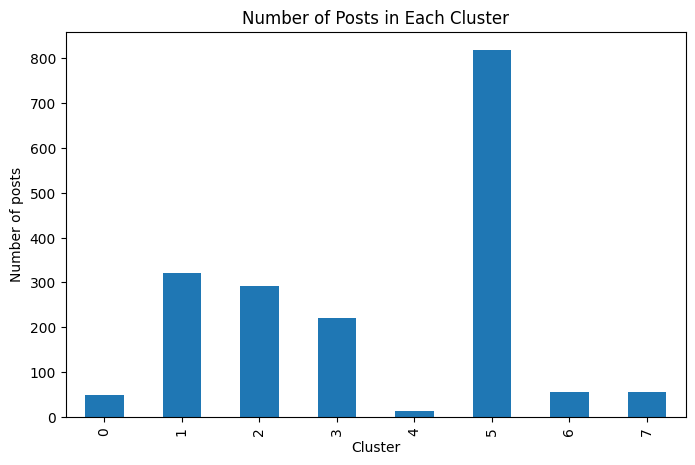

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of posts")
plt.title("Number of Posts in Each Cluster")
plt.show()

In [59]:
print(results_svd_df)

    k  silhouette   calinski    davies
0   2    0.030099  40.318476  5.934200
1   3    0.026259  36.976755  5.519941
2   4    0.031230  33.869535  4.068304
3   5    0.030271  32.065656  4.372018
4   6    0.035217  31.056427  3.665008
5   7    0.028567  29.267420  4.079439
6   8    0.043618  30.602365  3.677288
7   9    0.029949  27.643529  3.620901
8  10    0.040907  26.922796  3.382206


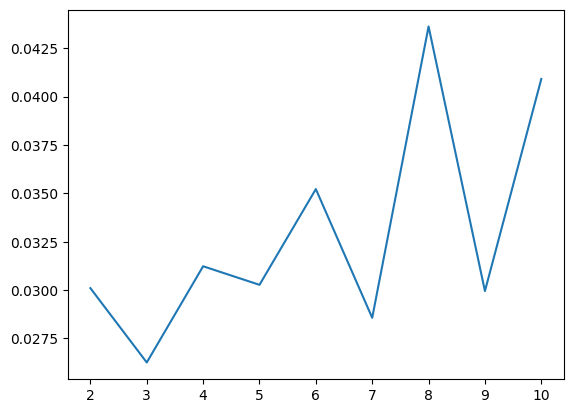

In [60]:
plt.plot(results_svd_df["k"], results_svd_df["silhouette"])

In [61]:
print(cluster_names)

{np.int32(0): 'thank you / thank / you', np.int32(1): 'the / is / in', np.int32(2): 'you / do / do you', np.int32(3): 'and / to / the', np.int32(4): 'happy birthday / birthday / birthday to', np.int32(5): 'is / this / it', np.int32(6): 'de / que / em', np.int32(7): 'are / are you / you'}


Bar Chart

<Axes: xlabel='cluster'>

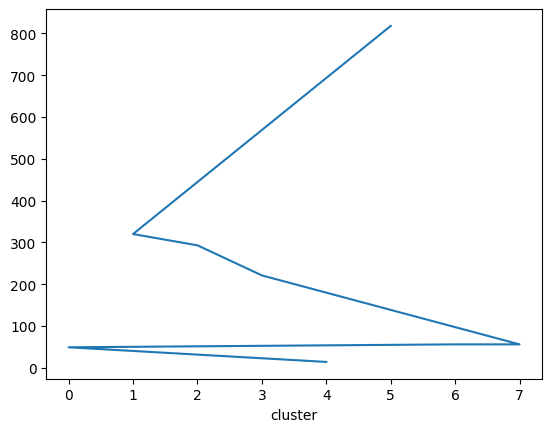

In [64]:
df["cluster"].value_counts().plot()

Sample Cleaned Text

In [65]:
df[["content", "final_text"]].head()

,content,final_text
1,Yet if a Verizon customer travels outside of t...,yet if a verizon customer travels outside of t...
2,Where is the 5g we was promised 2 years ago,where is the g we was promised years ago
3,Your customer service may be the worst on eart...,your customer service may be the worst on eart...
4,And what does this picture suppose to mean? Th...,and what does this picture suppose to mean tha...
7,ATT Business customer service is HORRIBLE! Ta...,att business customer service is horrible talk...
